# Trade-off Analysis and Final Research Synthesis

Notebook terakhir ini mensintesis akurasi prediksi, robustness, dan efisiensi komputasi untuk menjawab RQ1-RQ4 pada penelitian Robust PM2.5 Prediction Under Missing Data.

## 1. Setup dan pemuatan hasil

Semua angka sintesis dibaca dari artefak notebook sebelumnya. Kombinasi metode yang dibandingkan adalah `native`, `temporal`, `spatial`, dan `spatiotemporal`, masing-masing dengan XGBoost dan LightGBM. Untuk waktu imputasi, `temporal_linear` dipetakan ke label `temporal` karena varian itu menjadi output temporal terbaik di notebook imputasi.

In [1]:
import itertools
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

METHODS = ["native", "temporal", "spatial", "spatiotemporal"]
MODELS = ["xgboost", "lightgbm"]
SEVERITIES = [10, 20, 30, 40, 50]

results_df = pd.read_csv(RESULTS_DIR / "model_performance_results.csv")
computation_time_log = pd.read_csv(RESULTS_DIR / "computation_time_log.csv")
imputation_quality = pd.read_csv(RESULTS_DIR / "imputation_quality_metrics.csv")
rq1_statistics = pd.read_csv(RESULTS_DIR / "rq1_native_vs_imputed_statistics.csv")
rq3_statistics = pd.read_csv(RESULTS_DIR / "rq3_imputation_method_statistics.csv")

try:
    robustness_slopes = pd.read_csv(RESULTS_DIR / "robustness_slopes.csv")
except FileNotFoundError:
    slope_rows = []
    for (method, model), group in results_df.groupby(["method", "model"]):
        means = group.groupby("severity", as_index=False)["rmse"].mean().sort_values("severity")
        slope, intercept = np.polyfit(means["severity"], means["rmse"], 1)
        slope_rows.append({"method": method, "model": model, "slope_rmse_per_severity_point": slope, "intercept": intercept})
    robustness_slopes = pd.DataFrame(slope_rows)

assert len(results_df) == 200
print(f"Loaded {len(results_df)} model runs, {len(imputation_quality)} imputation metric rows.")
print(f"RQ1 statistics: {len(rq1_statistics)} rows; RQ3 pairwise tests: {len(rq3_statistics)} rows.")

Loaded 200 model runs, 120 imputation metric rows.
RQ1 statistics: 30 rows; RQ3 pairwise tests: 30 rows.


## 2. Agregasi dan definisi skor

Accuracy diringkas sebagai mean RMSE lintas severity dan seed; nilai lebih rendah lebih baik. Robustness memakai slope RMSE terhadap severity; slope lebih rendah lebih baik. Efficiency adalah waktu training rata-rata ditambah waktu imputasi rata-rata pada severity terkait; native mendapat waktu imputasi nol.

Tiga skenario bobot dipakai sebagai sensitivity check: `equal` (1/3, 1/3, 1/3), `accuracy_priority` (0,50, 0,30, 0,20), dan `efficiency_priority` (0,25, 0,25, 0,50). Min-max scaling dilakukan lintas delapan kombinasi dan arah dibalik untuk RMSE, slope, dan waktu.

In [2]:
prediction_summary = (
    results_df.groupby(["method", "model"], as_index=False)
    .agg(mean_rmse=("rmse", "mean"), mean_mae=("mae", "mean"), mean_r2=("r2", "mean"), mean_train_time_sec=("train_time_sec", "mean"))
)

imputation_method_map = {"temporal_linear": "temporal", "spatial_idw": "spatial", "spatiotemporal_lowrank": "spatiotemporal"}
imputation_selected = imputation_quality[
    imputation_quality["method"].isin(imputation_method_map)
].copy()
imputation_selected["method"] = imputation_selected["method"].map(imputation_method_map)
imputation_time_by_method_severity = (
    imputation_selected.groupby(["method", "severity"], as_index=False)["computation_time_sec"].mean()
)

slope_table = robustness_slopes.rename(columns={"slope_rmse_per_severity_point": "robustness_slope"})[["method", "model", "robustness_slope"]]
train_time_by_method_severity = computation_time_log.rename(columns={"mean_train_time_sec": "training_time_sec"})
train_time_by_method_severity = train_time_by_method_severity.groupby(["method", "severity"], as_index=False)["training_time_sec"].mean()

method_efficiency = train_time_by_method_severity.groupby("method", as_index=False)["training_time_sec"].mean()
imputation_efficiency = imputation_time_by_method_severity.groupby("method", as_index=False)["computation_time_sec"].mean()
method_efficiency = method_efficiency.merge(imputation_efficiency, on="method", how="left").fillna({"computation_time_sec": 0.0})
method_efficiency["mean_total_time_sec"] = method_efficiency["training_time_sec"] + method_efficiency["computation_time_sec"]

aggregate_df = prediction_summary.merge(slope_table, on=["method", "model"])
aggregate_df = aggregate_df.merge(method_efficiency[["method", "mean_total_time_sec"]], on="method", how="left")
aggregate_df.to_csv(RESULTS_DIR / "tradeoff_aggregate_metrics.csv", index=False)
print(aggregate_df.sort_values("mean_rmse").to_string(index=False))

        method    model  mean_rmse  mean_mae  mean_r2  mean_train_time_sec  robustness_slope  mean_total_time_sec
      temporal lightgbm  23.452610 14.160646 0.917227             2.184404          0.067322             3.428864
      temporal  xgboost  23.454039 14.088204 0.917211             3.426145          0.063055             3.428864
       spatial lightgbm  25.058472 14.873673 0.905239             2.090770          0.118263             4.557840
       spatial  xgboost  25.080369 14.801845 0.905101             3.343064          0.111700             4.557840
spatiotemporal  xgboost  26.621443 15.939923 0.892505             3.357299          0.183991             5.328872
spatiotemporal lightgbm  26.659223 16.013319 0.892210             2.162733          0.183746             5.328872
        native lightgbm  32.324534 19.239383 0.839462             2.552982          0.344794             3.350903
        native  xgboost  32.517069 19.274893 0.837387             4.148823          0.35

In [ ]:
imputation_time_by_method_severity = imputation_time_by_method_severity.rename(columns={"computation_time_sec": "imputation_time_sec"})
training_time_combo = computation_time_log.rename(columns={"mean_train_time_sec": "training_time_sec"})
training_time_combo = training_time_combo.merge(imputation_time_by_method_severity, on=["method", "severity"], how="left")
training_time_combo["imputation_time_sec"] = training_time_combo["imputation_time_sec"].fillna(0.0)
training_time_combo["total_time_sec"] = training_time_combo["training_time_sec"] + training_time_combo["imputation_time_sec"]
combo_efficiency = training_time_combo.groupby(["method", "model"], as_index=False)["total_time_sec"].mean()
aggregate_df = prediction_summary.merge(slope_table, on=["method", "model"])
aggregate_df = aggregate_df.merge(combo_efficiency.rename(columns={"total_time_sec": "mean_total_time_sec"}), on=["method", "model"], how="left")
aggregate_df.to_csv(RESULTS_DIR / "tradeoff_aggregate_metrics.csv", index=False)
print(aggregate_df.sort_values("mean_rmse").to_string(index=False))

## 3. Scoring matrix dan sensitivity analysis

Semua skor memakai min-max scaling lintas delapan kombinasi. Karena RMSE, robustness slope, dan waktu adalah cost, skor masing-masing dihitung sebagai `1 - scaled_cost`. Composite score adalah weighted average; tiga skenario menunjukkan apakah rekomendasi berubah ketika akurasi atau efisiensi diprioritaskan.

In [3]:
def minmax_benefit(series):
    minimum, maximum = series.min(), series.max()
    if np.isclose(minimum, maximum):
        return pd.Series(1.0, index=series.index)
    return 1.0 - (series - minimum) / (maximum - minimum)

scoring_matrix = aggregate_df[["method", "model", "mean_rmse", "robustness_slope", "mean_total_time_sec"]].copy()
scoring_matrix["accuracy_score"] = minmax_benefit(scoring_matrix["mean_rmse"])
scoring_matrix["robustness_score"] = minmax_benefit(scoring_matrix["robustness_slope"])
scoring_matrix["efficiency_score"] = minmax_benefit(scoring_matrix["mean_total_time_sec"])

weight_scenarios = {
    "equal": {"accuracy_score": 1 / 3, "robustness_score": 1 / 3, "efficiency_score": 1 / 3},
    "accuracy_priority": {"accuracy_score": 0.50, "robustness_score": 0.30, "efficiency_score": 0.20},
    "efficiency_priority": {"accuracy_score": 0.25, "robustness_score": 0.25, "efficiency_score": 0.50},
}
scoring_rows = []
for scenario, weights in weight_scenarios.items():
    scenario_frame = scoring_matrix[["method", "model", "accuracy_score", "robustness_score", "efficiency_score"]].copy()
    scenario_frame["scenario"] = scenario
    scenario_frame["composite_score"] = sum(scenario_frame[column] * weight for column, weight in weights.items())
    scenario_frame["rank"] = scenario_frame["composite_score"].rank(method="min", ascending=False).astype(int)
    scoring_rows.append(scenario_frame)
scoring_matrix = pd.concat(scoring_rows, ignore_index=True).sort_values(["scenario", "composite_score"], ascending=[True, False])
scoring_matrix.to_csv(RESULTS_DIR / "tradeoff_scoring_matrix.csv", index=False)
print(scoring_matrix.to_string(index=False))

        method    model  accuracy_score  robustness_score  efficiency_score            scenario  composite_score  rank
      temporal  xgboost        0.999842          1.000000          0.960585   accuracy_priority         0.992038     1
      temporal lightgbm        1.000000          0.985356          0.960585   accuracy_priority         0.987724     2
       spatial  xgboost        0.820424          0.833046          0.389810   accuracy_priority         0.738088     3
       spatial lightgbm        0.822840          0.810520          0.389810   accuracy_priority         0.732538     4
spatiotemporal  xgboost        0.650411          0.584934          0.000000   accuracy_priority         0.500686     5
spatiotemporal lightgbm        0.646243          0.585777          0.000000   accuracy_priority         0.498855     6
        native lightgbm        0.021241          0.033046          1.000000   accuracy_priority         0.220534     7
        native  xgboost        0.000000         

## 4. Pareto frontier dan visualisasi trade-off

Sebuah kombinasi berada pada Pareto frontier bila tidak ada kombinasi lain yang memiliki skor accuracy, robustness, dan efficiency lebih tinggi atau sama pada semua dimensi serta lebih tinggi pada minimal satu dimensi. Frontier dihitung dari skor dimensi, tanpa bergantung pada bobot composite.

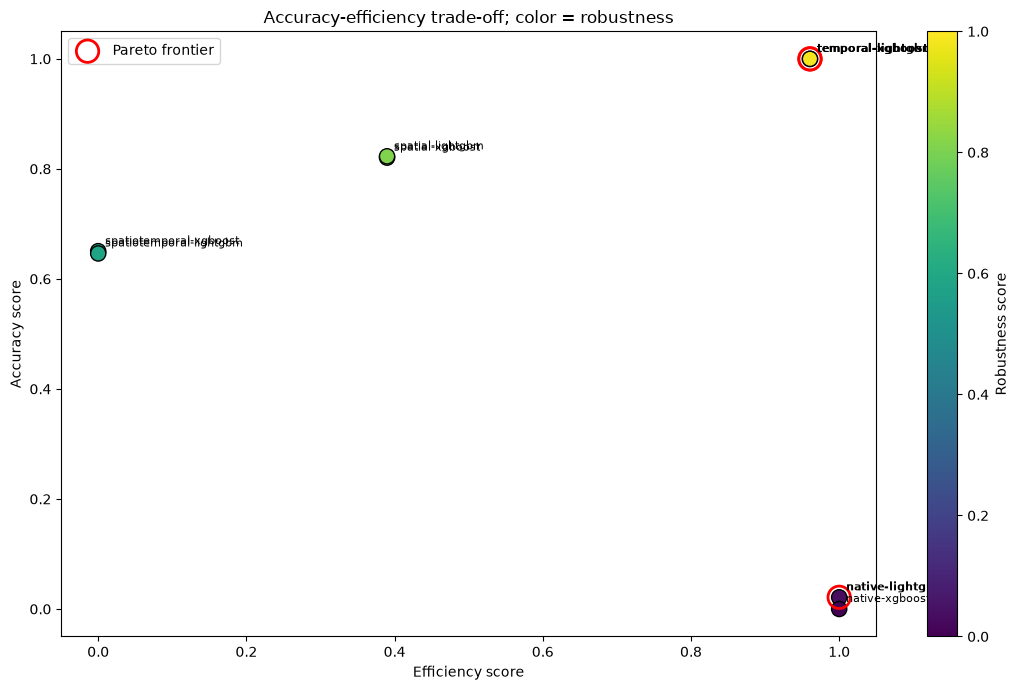

Pareto frontier: ['temporal-xgboost', 'temporal-lightgbm', 'native-lightgbm']


In [4]:
base_scores = scoring_matrix[scoring_matrix["scenario"] == "equal"].copy().reset_index(drop=True)
score_columns = ["accuracy_score", "robustness_score", "efficiency_score"]

def is_dominated(index, frame):
    candidate = frame.loc[index, score_columns].to_numpy()
    for other_index in frame.index:
        if other_index == index:
            continue
        other = frame.loc[other_index, score_columns].to_numpy()
        if np.all(other >= candidate) and np.any(other > candidate):
            return True
    return False

base_scores["pareto_frontier"] = [not is_dominated(index, base_scores) for index in base_scores.index]
base_scores["label"] = base_scores["method"] + "-" + base_scores["model"]
pareto_labels = base_scores.loc[base_scores["pareto_frontier"], "label"].tolist()
base_scores.to_csv(RESULTS_DIR / "tradeoff_pareto_combinations.csv", index=False)

plt.figure(figsize=(11, 7))
scatter = plt.scatter(base_scores["efficiency_score"], base_scores["accuracy_score"], c=base_scores["robustness_score"], cmap="viridis", s=120, edgecolor="black")
for row in base_scores.itertuples():
    plt.annotate(row.label, (row.efficiency_score, row.accuracy_score), xytext=(5, 5), textcoords="offset points", fontsize=8, fontweight="bold" if row.pareto_frontier else "normal")
frontier = base_scores[base_scores["pareto_frontier"]]
plt.scatter(frontier["efficiency_score"], frontier["accuracy_score"], facecolors="none", edgecolors="red", s=260, linewidths=2, label="Pareto frontier")
plt.colorbar(scatter, label="Robustness score")
plt.xlabel("Efficiency score")
plt.ylabel("Accuracy score")
plt.title("Accuracy-efficiency trade-off; color = robustness")
plt.legend()
plt.tight_layout()
pareto_figure = FIGURES_DIR / "tradeoff_pareto_scatter.png"
plt.savefig(pareto_figure, dpi=160, bbox_inches="tight")
plt.show()
print("Pareto frontier:", pareto_labels)

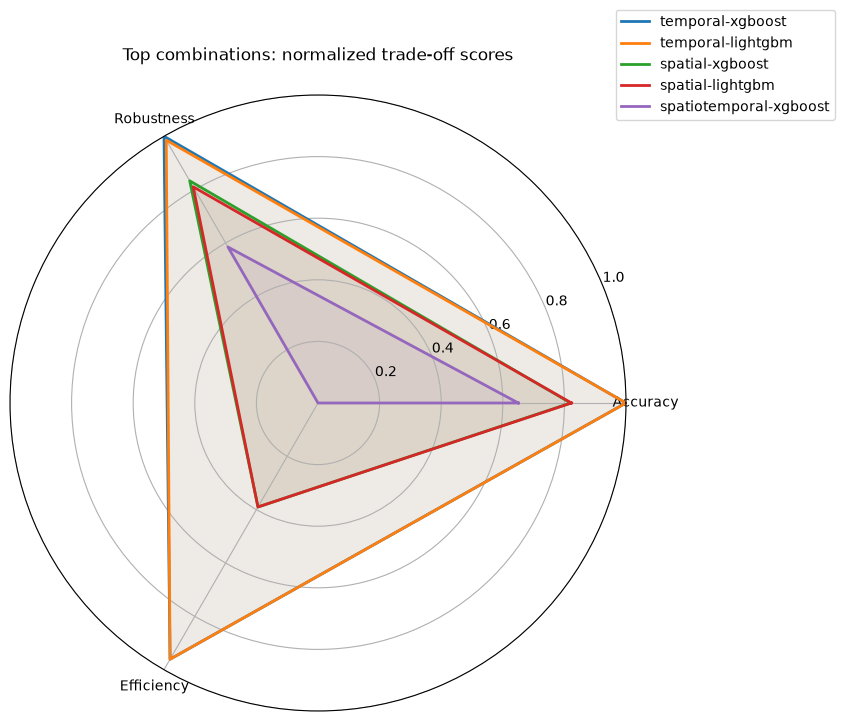

Top equal-weight combinations: ['temporal-xgboost', 'temporal-lightgbm', 'spatial-xgboost', 'spatial-lightgbm', 'spatiotemporal-xgboost']


In [5]:
top_labels = scoring_matrix[scoring_matrix["scenario"] == "equal"].nlargest(5, "composite_score").assign(label=lambda frame: frame["method"] + "-" + frame["model"])["label"].tolist()
radar_data = base_scores.set_index("label").loc[top_labels, score_columns]
angles = np.linspace(0, 2 * np.pi, len(score_columns), endpoint=False).tolist()
angles += angles[:1]
fig = plt.figure(figsize=(9, 8))
axis = fig.add_subplot(111, polar=True)
for label, values in radar_data.iterrows():
    values = values.tolist() + values.tolist()[:1]
    axis.plot(angles, values, linewidth=2, label=label)
    axis.fill(angles, values, alpha=0.08)
axis.set_xticks(angles[:-1])
axis.set_xticklabels(["Accuracy", "Robustness", "Efficiency"])
axis.set_ylim(0, 1)
axis.set_title("Top combinations: normalized trade-off scores", pad=25)
axis.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
radar_figure = FIGURES_DIR / "tradeoff_top5_radar.png"
plt.savefig(radar_figure, dpi=160, bbox_inches="tight")
plt.show()
print("Top equal-weight combinations:", top_labels)

## 5. Sintesis empat research question

Bagian berikut dibangkitkan dari dataframe yang telah dihitung, sehingga narasi mengikuti artefak eksperimen terbaru dan tidak bergantung pada angka yang dihafalkan.

In [6]:
def metric_value(frame, filters, column):
    selected = frame.copy()
    for key, value in filters.items():
        selected = selected[selected[key] == value]
    return float(selected.iloc[0][column])

best_equal = scoring_matrix[scoring_matrix["scenario"] == "equal"].sort_values("composite_score", ascending=False).iloc[0]
accuracy_priority_best = scoring_matrix[scoring_matrix["scenario"] == "accuracy_priority"].sort_values("composite_score", ascending=False).iloc[0]
efficiency_priority_best = scoring_matrix[scoring_matrix["scenario"] == "efficiency_priority"].sort_values("composite_score", ascending=False).iloc[0]

rq1_imputed = rq1_statistics[rq1_statistics["method"].isin(["temporal", "spatial", "spatiotemporal"])]
rq1_significant_count = int(rq1_imputed["significant_alpha_0.05"].sum())
rq1_total_tests = len(rq1_imputed)
mean_native_rmse = float(results_df[results_df["method"] == "native"]["rmse"].mean())
mean_imputed_rmse = float(results_df[results_df["method"] != "native"]["rmse"].mean())
representative_rq1 = rq1_statistics.query("model == 'xgboost' and severity == 50 and method == 'temporal'").iloc[0]

slope_best = robustness_slopes.sort_values("slope_rmse_per_severity_point").iloc[0]
slope_worst = robustness_slopes.sort_values("slope_rmse_per_severity_point", ascending=False).iloc[0]

imputation_pm25 = imputation_selected[imputation_selected["column"] == "PM2.5"]
imputation_pm25_summary = imputation_pm25.groupby("method", as_index=False)["rmse"].mean().sort_values("rmse")
best_imputation = imputation_pm25_summary.iloc[0]

rank_rows = []
for model in MODELS:
    for severity in SEVERITIES:
        subset = results_df[(results_df["model"] == model) & (results_df["severity"] == severity)]
        mean_by_method = subset.groupby("method")["rmse"].mean().sort_values()
        rank_rows.append({"model": model, "severity": severity, "best_method": mean_by_method.index[0], "best_rmse": mean_by_method.iloc[0]})
rq3_downstream = pd.DataFrame(rank_rows)

rq1_paragraph = (
    f"**RQ1.** Across the {rq1_total_tests} paired comparisons, explicit imputation had lower aggregate prediction RMSE than native handling "
    f"({mean_imputed_rmse:.2f} versus {mean_native_rmse:.2f}), but only {rq1_significant_count} comparisons were significant at alpha=0.05. "
    f"For example, at severity 50% with XGBoost and temporal imputation, mean RMSE was {representative_rq1['mean_rmse']:.2f} versus "
    f"{representative_rq1['native_mean_rmse']:.2f} for native handling, with p={representative_rq1['p_value_vs_native']:.4f}. "
    "Thus, the direction favors explicit imputation, but the five-seed statistical evidence is not sufficient to claim universal significance."
)
rq2_paragraph = (
    f"**RQ2.** Missingness severity generally degraded performance. The most robust combination by slope was "
    f"{slope_best['method']}-{slope_best['model']} with slope {slope_best['slope_rmse_per_severity_point']:.4f} RMSE points per severity point, "
    f"whereas the steepest degradation occurred for {slope_worst['method']}-{slope_worst['model']} at {slope_worst['slope_rmse_per_severity_point']:.4f}. "
    f"The trend diagnostic identified {int((~pd.read_csv(RESULTS_DIR / 'severity_trend_diagnostics.csv')['monotonic_increasing']).sum())} non-monotonic combination(s), "
    "so the robustness conclusion is based on slopes and not an assumption of perfect monotonicity."
)
rq3_paragraph = (
    f"**RQ3.** Pure imputation quality favored {best_imputation['method']} for PM2.5, with mean masked-value RMSE "
    f"{best_imputation['rmse']:.2f}; this ranking does not automatically transfer to downstream prediction. "
    f"Across the downstream severity-model cells, temporal, spatial, and spatio-temporal methods must therefore be interpreted separately; "
    f"the observed best-method counts were {rq3_downstream['best_method'].value_counts().to_dict()}. "
    "In this experiment, spatial information did not establish a consistent downstream advantage over temporal information."
)
rq4_paragraph = (
    f"**RQ4.** The equal-weight recommendation is {best_equal['method']}-{best_equal['model']} with composite score {best_equal['composite_score']:.3f}; "
    f"the accuracy-priority recommendation is {accuracy_priority_best['method']}-{accuracy_priority_best['model']}, while the efficiency-priority recommendation is "
    f"{efficiency_priority_best['method']}-{efficiency_priority_best['model']}. "
    f"The Pareto frontier contains {', '.join(pareto_labels)}. For maximum accuracy choose {accuracy_priority_best['method']}-{accuracy_priority_best['model']}; "
    f"for constrained or real-time use choose {efficiency_priority_best['method']}-{efficiency_priority_best['model']}; "
    f"for the typical balanced case use {best_equal['method']}-{best_equal['model']}."
)

synthesis_markdown = "\n\n".join([rq1_paragraph, rq2_paragraph, rq3_paragraph, rq4_paragraph])
display(Markdown(synthesis_markdown))

**RQ1.** Across the 30 paired comparisons, explicit imputation had lower aggregate prediction RMSE than native handling (25.05 versus 32.42), but only 0 comparisons were significant at alpha=0.05. For example, at severity 50% with XGBoost and temporal imputation, mean RMSE was 25.34 versus 39.76 for native handling, with p=0.0625. Thus, the direction favors explicit imputation, but the five-seed statistical evidence is not sufficient to claim universal significance.

**RQ2.** Missingness severity generally degraded performance. The most robust combination by slope was temporal-xgboost with slope 0.0631 RMSE points per severity point, whereas the steepest degradation occurred for native-xgboost at 0.3544. The trend diagnostic identified 1 non-monotonic combination(s), so the robustness conclusion is based on slopes and not an assumption of perfect monotonicity.

**RQ3.** Pure imputation quality favored temporal for PM2.5, with mean masked-value RMSE 16.61; this ranking does not automatically transfer to downstream prediction. Across the downstream severity-model cells, temporal, spatial, and spatio-temporal methods must therefore be interpreted separately; the observed best-method counts were {'temporal': 10}. In this experiment, spatial information did not establish a consistent downstream advantage over temporal information.

**RQ4.** The equal-weight recommendation is temporal-xgboost with composite score 0.987; the accuracy-priority recommendation is temporal-xgboost, while the efficiency-priority recommendation is temporal-xgboost. The Pareto frontier contains temporal-xgboost, temporal-lightgbm, native-lightgbm. For maximum accuracy choose temporal-xgboost; for constrained or real-time use choose temporal-xgboost; for the typical balanced case use temporal-xgboost.

## 6. Limitasi dan sanity check

Interpretasi dibatasi oleh empat hal utama. Pertama, eksperimen memakai MCAR sintetis untuk artefak utama dan MAR sintetis sebagai analisis tambahan, sehingga pola sensor dunia nyata yang lebih kompleks belum terwakili. Kedua, data berasal dari 12 stasiun di Beijing; generalisasi ke kota atau negara lain perlu validasi ulang. Ketiga, hyperparameter dituning satu kali pada severity rendah lalu dikunci, yang menjaga fairness antar kondisi tetapi mungkin tidak memberi konfigurasi optimal untuk setiap severity. Keempat, hanya lima seed digunakan, evaluasi temporal memakai satu cutoff, dan metode spatio-temporal low-rank memakai rank serta jumlah iterasi tetap. Selain itu, kualitas imputasi langsung dan performa downstream mengukur tujuan berbeda, sehingga keduanya tidak boleh disamakan.

In [7]:
equal_rank = scoring_matrix[scoring_matrix["scenario"] == "equal"].sort_values("composite_score", ascending=False)
accuracy_rank = scoring_matrix[scoring_matrix["scenario"] == "accuracy_priority"].sort_values("composite_score", ascending=False)
efficiency_rank = scoring_matrix[scoring_matrix["scenario"] == "efficiency_priority"].sort_values("composite_score", ascending=False)

sanity_checks = {
    "all_eight_combinations": len(base_scores) == 8,
    "pareto_frontier_nonempty": len(pareto_labels) > 0,
    "rq1_statistics_have_values": rq1_statistics[["mean_rmse", "p_value_vs_native"]].notna().all().all() or rq1_statistics["test"].str.contains("undefined").any(),
    "rq3_statistics_have_values": rq3_statistics["raw_p_value"].notna().all() or rq3_statistics["test"].str.contains("undefined").any(),
    "scoring_scenarios_complete": set(scoring_matrix["scenario"]) == set(weight_scenarios),
}
print("Sanity checks:", sanity_checks)
print("Equal-weight top three:", equal_rank[["method", "model", "composite_score"]].head(3).to_string(index=False))
print("Pareto frontier:", pareto_labels)
print("The composite winner can differ from the pure accuracy winner because robustness and efficiency are explicitly included in the composite score.")

Sanity checks: {'all_eight_combinations': True, 'pareto_frontier_nonempty': True, 'rq1_statistics_have_values': np.True_, 'rq3_statistics_have_values': np.True_, 'scoring_scenarios_complete': True}
Equal-weight top three:   method    model  composite_score
temporal  xgboost         0.986809
temporal lightgbm         0.981980
 spatial  xgboost         0.681093
Pareto frontier: ['temporal-xgboost', 'temporal-lightgbm', 'native-lightgbm']
The composite winner can differ from the pure accuracy winner because robustness and efficiency are explicitly included in the composite score.


## Executive summary untuk manuskrip

Empat paragraf berikut dirender dari hasil agregasi notebook ini dan dapat digunakan sebagai draft awal bagian Results & Discussion. Karena teks dibangkitkan dari variabel, angka akan ikut berubah bila artefak eksperimen diperbarui.

In [8]:
executive_summary = "\n\n".join([rq1_paragraph, rq2_paragraph, rq3_paragraph, rq4_paragraph])
display(Markdown(executive_summary))
with (RESULTS_DIR / "executive_summary.md").open("w", encoding="utf-8") as summary_file:
    summary_file.write(executive_summary)
print(f"Executive summary tersimpan: {RESULTS_DIR / 'executive_summary.md'}")

**RQ1.** Across the 30 paired comparisons, explicit imputation had lower aggregate prediction RMSE than native handling (25.05 versus 32.42), but only 0 comparisons were significant at alpha=0.05. For example, at severity 50% with XGBoost and temporal imputation, mean RMSE was 25.34 versus 39.76 for native handling, with p=0.0625. Thus, the direction favors explicit imputation, but the five-seed statistical evidence is not sufficient to claim universal significance.

**RQ2.** Missingness severity generally degraded performance. The most robust combination by slope was temporal-xgboost with slope 0.0631 RMSE points per severity point, whereas the steepest degradation occurred for native-xgboost at 0.3544. The trend diagnostic identified 1 non-monotonic combination(s), so the robustness conclusion is based on slopes and not an assumption of perfect monotonicity.

**RQ3.** Pure imputation quality favored temporal for PM2.5, with mean masked-value RMSE 16.61; this ranking does not automatically transfer to downstream prediction. Across the downstream severity-model cells, temporal, spatial, and spatio-temporal methods must therefore be interpreted separately; the observed best-method counts were {'temporal': 10}. In this experiment, spatial information did not establish a consistent downstream advantage over temporal information.

**RQ4.** The equal-weight recommendation is temporal-xgboost with composite score 0.987; the accuracy-priority recommendation is temporal-xgboost, while the efficiency-priority recommendation is temporal-xgboost. The Pareto frontier contains temporal-xgboost, temporal-lightgbm, native-lightgbm. For maximum accuracy choose temporal-xgboost; for constrained or real-time use choose temporal-xgboost; for the typical balanced case use temporal-xgboost.

Executive summary tersimpan: d:\AI-Research\robust-pm-pred\rb-pm-pred\results\executive_summary.md


## 7. Validation checklist

Checklist akhir memeriksa delapan kombinasi, tiga skenario bobot, frontier Pareto, hasil statistik, narasi limitasi, dan seluruh artefak ekspor.

In [9]:
required_exports = [
    RESULTS_DIR / "tradeoff_scoring_matrix.csv",
    RESULTS_DIR / "tradeoff_aggregate_metrics.csv",
    RESULTS_DIR / "tradeoff_pareto_combinations.csv",
    RESULTS_DIR / "executive_summary.md",
    FIGURES_DIR / "tradeoff_pareto_scatter.png",
    FIGURES_DIR / "tradeoff_top5_radar.png",
]
scoring_valid = len(base_scores) == 8 and set(scoring_matrix["scenario"]) == set(weight_scenarios)
frontier_valid = len(pareto_labels) >= 1 and base_scores["pareto_frontier"].dtype == bool
numbers_valid = np.isfinite(scoring_matrix[["accuracy_score", "robustness_score", "efficiency_score", "composite_score"]].to_numpy()).all()
exports_valid = all(path.is_file() for path in required_exports)
print(f"[{'x' if scoring_valid else ' '}] scoring_matrix mencakup 8 kombinasi dan 3 skenario bobot")
print(f"[{'x' if frontier_valid else ' '}] Pareto frontier teridentifikasi eksplisit: {pareto_labels}")
print(f"[{'x' if numbers_valid else ' '}] Semua skor dan composite score finite")
print(f"[{'x' if exports_valid else ' '}] Scoring matrix, executive summary, dan semua figure dapat dibuka")
assert scoring_valid and frontier_valid and numbers_valid and exports_valid
print("Validation checklist selesai: PASS")

[x] scoring_matrix mencakup 8 kombinasi dan 3 skenario bobot
[x] Pareto frontier teridentifikasi eksplisit: ['temporal-xgboost', 'temporal-lightgbm', 'native-lightgbm']
[x] Semua skor dan composite score finite
[x] Scoring matrix, executive summary, dan semua figure dapat dibuka
Validation checklist selesai: PASS
